# 4-2 파이토치의 데이터 파이프라인

본 노트북은 본문 4-2 절의 코드 예제([코드 4-7] ~ [코드 4-17])를 절 흐름 그대로 모은 것이다. `Dataset` / `DataLoader` 를 사용하는 파이토치 표준 데이터 파이프라인을 회오리 데이터로 구성한다.

다루는 내용
- `Dataset` 상속 클래스 정의 (`__init__`, `__len__`, `__getitem__`)
- 생성자/`__getitem__` 의 역할 분담과 데이터 변환 객체 주입(의존성 주입)
- `random_split()` 으로 훈련·검증·평가 분리
- `DataLoader` 로 미니배치 데이터로더 생성
- 미니배치 + 가중 평균 손실 학습 함수

## 라이브러리 import 와 시드 고정

In [1]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [2]:
# 참고 - 라이브러리 import 와 시드 고정
import copy
import csv
import random
import time
from collections import OrderedDict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (
    ConcatDataset, DataLoader, Dataset, random_split,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## [코드 4-7] 회오리 모양 데이터셋의 정의

`Dataset` 을 상속해 `__init__`, `__len__`, `__getitem__` 세 메서드를 구현한다. CSV 파일을 생성자에서 텐서로 읽어 두고, 두 필수 메서드는 준비된 텐서를 사용한다.

> 본문 경로는 `'../data/ch3_spiral_data.csv'` 이지만, 노트북은 `notebooks/ch04/` 에 위치하므로 `'../../data/...'` 가 정확하다. (이 경로 차이는 `_book` 에 기록한다.)

In [3]:
# 코드 4-7 - 회오리 모양 데이터셋의 정의

# 3-3절 회오리 모양 데이터를 사용해 정의한 파이토치 데이터셋 클래스
class SpiralDataset(Dataset):
    # CSV 형식 파일에서 데이터를 불러와 텐서 형태로 변환
    def __init__(self, csv_path):
        X_list, Y_list = [], []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                X_list.append([float(row['x1']), float(row['x2'])])
                Y_list.append(int(row['label']))
        self.X = torch.tensor(X_list)
        self.Y = torch.tensor(Y_list, dtype=torch.long)

    # 필수 오버라이딩 메서드 1: 데이터셋의 전체 샘플 개수를 반환
    def __len__(self):
        return len(self.X)

    # 필수 오버라이딩 메서드 2: 인덱스 idx에 해당하는 데이터 샘플을 반환
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

## [코드 4-8] 데이터셋의 사용법

`len()` 은 `__len__()`, 인덱싱·슬라이싱은 `__getitem__()` 과 연결된다. 슬라이싱 결과도 입력 묶음과 정답 묶음의 두 텐서로 구성된다.

In [4]:
# 코드 4-8 - 데이터셋의 사용법
# 데이터셋 객체 생성
csv_path = '../../data/ch3_spiral_data.csv'         # 데이터 파일의 경로
spiral_dataset = SpiralDataset(csv_path)            # 데이터셋 객체

# 데이터셋 객체 사용
print(f'전체 샘플의 수: {len(spiral_dataset)}')     # 내장 함수 len(): __len__() 메서드 연결
print(f'첫 번째 샘플: {spiral_dataset[0]}')         # 인덱싱: __getitem__() 메서드 연결
print(f'마지막 샘플 3개:\n{spiral_dataset[-3:]}')   #  __getitem__()에 범위 정보가 전달

전체 샘플의 수: 900
첫 번째 샘플: (tensor([ 0.2178, -0.0858]), tensor(0))
마지막 샘플 3개:
(tensor([[-0.8599, -0.1290],
        [-0.3069,  0.3311],
        [ 0.2302, -0.2517]]), tensor([2, 1, 0]))


## [코드 4-9] 결과는 같지만 메서드별 역할을 조정한 `SpiralDataset` 클래스

일반적인 데이터셋은 생성자에서 데이터를 읽어 두기만 하고, 텐서 변환은 `__getitem__()` 이 샘플 단위로 담당한다.

In [5]:
# 코드 4-9 - 결과는 같지만 메서드별 역할을 조정한 SpiralDataset 클래스

class SpiralDataset(Dataset):
    # CSV 형식 파일에서 데이터를 불러와 리스트에 저장
    def __init__(self, csv_path):
        self.X_list, self.Y_list = [], []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.X_list.append([float(row['x1']), float(row['x2'])])
                self.Y_list.append(int(row['label']))

    def __len__(self):
        return len(self.X_list)

    # 인덱스 idx에 해당하는 샘플을 텐서로 변환해 반환
    def __getitem__(self, idx):
        x = torch.tensor(self.X_list[idx])
        y = torch.tensor(self.Y_list[idx], dtype=torch.long)
        return x, y


# 동일하게 동작하는지 확인
spiral_dataset = SpiralDataset(csv_path)
print(f'첫 번째 샘플: {spiral_dataset[0]}')

첫 번째 샘플: (tensor([ 0.2178, -0.0858]), tensor(0))


In [6]:
# 코드 4-8 - 데이터셋의 사용법
# 데이터셋 객체 생성
csv_path = '../../data/ch3_spiral_data.csv'         # 데이터 파일의 경로
spiral_dataset = SpiralDataset(csv_path)            # 데이터셋 객체

# 데이터셋 객체 사용
print(f'전체 샘플의 수: {len(spiral_dataset)}')     # 내장 함수 len(): __len__() 메서드 연결
print(f'첫 번째 샘플: {spiral_dataset[0]}')         # 인덱싱: __getitem__() 메서드 연결
print(f'마지막 샘플 3개:\n{spiral_dataset[-3:]}')   #  __getitem__()에 범위 정보가 전달

전체 샘플의 수: 900
첫 번째 샘플: (tensor([ 0.2178, -0.0858]), tensor(0))
마지막 샘플 3개:
(tensor([[-0.8599, -0.1290],
        [-0.3069,  0.3311],
        [ 0.2302, -0.2517]]), tensor([2, 1, 0]))


## [코드 4-10] 32 비트 자료형 텐서로 변환하는 `__getitem__()` 메서드

소형 디바이스를 가정해 `torch.float` / `torch.int32` 로 변환하는 변형이다. 상황마다 클래스를 새로 만드는 것은 유지 보수에 불리하다는 점이 다음 코드(데이터 변환 객체)의 동기가 된다.

In [6]:
# 코드 4-10 - 32 비트 자료형 텐서로 변환하는 __getitem__() 메서드

class SpiralDataset32Bit(SpiralDataset):
    def __init__(self, csv_path):
        self.X_list, self.Y_list = [], []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.X_list.append([float(row['x1']), float(row['x2'])])
                self.Y_list.append(int(row['label']))

    def __len__(self):
        return len(self.X_list)

    # __init__, __len__ 은 부모 클래스 그대로 (...중간 생략...)
    def __getitem__(self, idx):
        x = torch.tensor(self.X_list[idx], dtype=torch.float)
        y = torch.tensor(self.Y_list[idx], dtype=torch.int32)
        return x, y

spiral_32 = SpiralDataset32Bit(csv_path)
x0, y0 = spiral_32[0]
print(f'x dtype: {x0.dtype}, y dtype: {y0.dtype}')

x dtype: torch.float32, y dtype: torch.int32


## [코드 4-11] 텐서로 변환하는 데이터 변환 객체

상황에 따라 달라지는 변환 부분만 호출 가능한 객체(`callable`)로 분리한다. 함수, 또는 `__call__()` 을 구현한 클래스 인스턴스로 만들 수 있다.

In [7]:
# 코드 4-11 - 텐서로 변환하는 데이터 변환 객체

# 함수로 만든 32 비트 텐서 변환 객체
def to_32bit_tensor(x, y):
    x = torch.tensor(x, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.int32)
    return x, y

# 클래스 인스턴스로 만든 64 비트 텐서 변환 객체
class To64BitTensor:
    def __call__(self, x, y):
        x = torch.tensor(x, dtype=torch.double)
        y = torch.tensor(y, dtype=torch.int64)
        return x, y
to_64bit_tensor = To64BitTensor()

# 동일한 입력에 대한 두 변환 결과 비교
x_in, y_in = [0.1, 0.2], 1
print('32 비트 변환:', to_32bit_tensor(x_in, y_in))
print('64 비트 변환:', to_64bit_tensor(x_in, y_in))

32 비트 변환: (tensor([0.1000, 0.2000]), tensor(1, dtype=torch.int32))
64 비트 변환: (tensor([0.1000, 0.2000], dtype=torch.float64), tensor(1))


## [코드 4-12] 데이터 변환 객체의 주입

데이터 변환 객체를 생성자 인자(`transform`)로 주입한다. 주입되지 않을 가능성(`None`)도 고려해 `__getitem__()` 에서 분기한다.

In [8]:
# 코드 4-12 - 데이터 변환 객체의 주입

class SpiralDataset(Dataset):
    # 생성자의 인자로 주입하며, 주입되지 않을 가능성도 고려해 기본값을 지정
    def __init__(self, csv_path, transform=None):
        self.X_list, self.Y_list = [], []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.X_list.append([float(row['x1']), float(row['x2'])])
                self.Y_list.append(int(row['label']))
        self.transform = transform              # 속성으로 저장

    def __len__(self):
        return len(self.X_list)

    def __getitem__(self, idx):
        x = self.X_list[idx]
        y = self.Y_list[idx]
        # 속성으로 정의해 둔 데이터 변환 객체를 함수처럼 사용해 데이터 변환
        if self.transform is not None:
            x, y = self.transform(x, y)
        return x, y

# 32비트 변환 객체와 64비트 변환 객체 각각을 주입해 데이터셋 객체 생성
spiral_dataset_32 = SpiralDataset(csv_path, to_32bit_tensor)
spiral_dataset_64 = SpiralDataset(csv_path, to_64bit_tensor)

print(spiral_dataset_32[0])     # 32 비트 텐서(torch.float32, torch.int32) 튜플
print(spiral_dataset_64[0])     # 64 비트 텐서(torch.float64, torch.int64) 튜플

(tensor([ 0.2178, -0.0858]), tensor(0, dtype=torch.int32))
(tensor([ 0.2178, -0.0858], dtype=torch.float64), tensor(0))


## 참고 - 학습용 기본 자료형 데이터셋 다시 생성

이후 분할·학습에서는 변환 객체 없이도 `__getitem__()` 이 `float32` / `long` 텐서를 반환하도록 [코드 4-9] 의 구현에 `transform` 인자를 더한 데이터셋을 사용한다.

In [9]:
# 참고 - 학습용 기본 자료형 데이터셋 다시 생성

class SpiralDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.X_list, self.Y_list = [], []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.X_list.append([float(row['x1']), float(row['x2'])])
                self.Y_list.append(int(row['label']))
        self.transform = transform

    def __len__(self):
        return len(self.X_list)

    def __getitem__(self, idx):
        if self.transform is None:
            x = torch.tensor(self.X_list[idx])
            y = torch.tensor(self.Y_list[idx], dtype=torch.long)
        else:
            x, y = self.transform(self.X_list[idx], self.Y_list[idx])
        return x, y


spiral_dataset = SpiralDataset(csv_path)
print(f'전체 샘플 수: {len(spiral_dataset)}')

전체 샘플 수: 900


## [코드 4-13] 데이터셋의 순서를 무작위로 섞어 훈련·검증·평가 데이터셋 분리

`random_split()` 으로 데이터셋을 6:2:2 로 나눈다. 재현성을 위해 `generator` 인자에 시드를 고정한 `torch.Generator()` 를 전달한다.

In [10]:
# 코드 4-13 - 데이터셋의 순서를 무작위로 섞어 훈련, 검증, 평가 데이터셋 분리

SEED = 42                                               # 난수 발생 시드값
sample_size = len(spiral_dataset)                       # 전체 데이터셋 샘플 수
train_ratio, valid_ratio, test_ratio = 0.6, 0.2, 0.2    # 구분 비율(합쳐서 1)
train_size = int(sample_size * train_ratio)             # 훈련 데이터셋의 샘플 수
valid_size = int(sample_size * valid_ratio)             # 검증 데이터셋의 샘플 수
test_size = sample_size - train_size - valid_size       # 평가 데이터셋의 샘플 수

train_set, valid_set, test_set = random_split(
    spiral_dataset,                                     # 구분 전 데이터셋
    [train_size, valid_size, test_size],                # 용도별 데이터셋의 샘플 수 리스트
    generator=torch.Generator().manual_seed(SEED),      # 난수 발생기 (시드값 고정 목적)
)

print(f'훈련 데이터셋의 샘플 수: {len(train_set)}')     
print(f'검증 데이터셋의 샘플 수: {len(valid_set)}')     
print(f'평가 데이터셋의 샘플 수: {len(test_set)}')      

훈련 데이터셋의 샘플 수: 540
검증 데이터셋의 샘플 수: 180
평가 데이터셋의 샘플 수: 180


## 참고 - 사이킷런 train_test_split() 으로 데이터 분할 (본문 각주 대응)

실무에서는 random_split() 대신 사이킷런(scikit-learn)의 train_test_split() 함수도 널리 사용한다. 부분 데이터셋마다 클래스 비율을 똑같이 유지해 주는 **층화 분할(stratify)** 이 대표적인 장점이다. 파이토치 외부 라이브러리이므로 본문에서는 다루지 않는다. (`pip install scikit-learn` 으로 설치)

In [11]:
# 참고(각주 8) - 사이킷런(scikit-learn)의 train_test_split() 함수로 데이터 분할
# 사이킷런은 파이토치와 별개인 전통 머신러닝 라이브러리로, 별도 설치가 필요하다.
#   pip install scikit-learn
# train_test_split() 함수는 데이터를 두 묶음으로 나누며, 다음과 같은 특징이 있다.
#   - stratify 인자: 지정한 정답 목록의 클래스 비율을 나눈 두 묶음 모두에 유지(층화 분할)
#   - random_state 인자: 분할 재현을 위한 시드값 (파이토치 난수 발생기와는 무관)
#   - 파이토치 Dataset이 아니라 리스트/넘파이 배열을 나누는 함수이므로, 여기서는
#     '샘플 인덱스'를 나눈 후 Subset으로 부분 데이터셋을 만든다.
#     (random_split()의 반환값도 같은 Subset 객체다)

from collections import Counter

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

indices = list(range(len(spiral_dataset)))      # 전체 샘플의 인덱스 (0 ~ 899)
labels = spiral_dataset.Y_list                  # 층화 분할의 기준이 되는 정답 목록

# 1차 분할: 전체를 훈련(60%)과 나머지(40%)로 나눈다.
train_idx, rest_idx = train_test_split(
    indices,
    test_size=0.4,          # 두 번째 묶음(검증+평가)의 비율
    stratify=labels,        # 클래스 비율을 유지하며 분할
    random_state=SEED,      # 시드값 고정 (재현 가능한 분할)
)
# 2차 분할: 나머지(40%)를 검증(20%)과 평가(20%)로 절반씩 나눈다.
# 1차에서 나뉜 묶음의 정답 목록을 stratify에 다시 지정해야 한다.
rest_labels = [labels[i] for i in rest_idx]
valid_idx, test_idx = train_test_split(
    rest_idx,
    test_size=0.5,
    stratify=rest_labels,
    random_state=SEED,
)

# 나눈 인덱스 목록으로 부분 데이터셋(Subset) 구성
train_set_sk = Subset(spiral_dataset, train_idx)
valid_set_sk = Subset(spiral_dataset, valid_idx)
test_set_sk = Subset(spiral_dataset, test_idx)
print(f'훈련/검증/평가 샘플 수: {len(train_set_sk)}/{len(valid_set_sk)}/{len(test_set_sk)}')

# 층화 분할의 효과: 모든 부분 데이터셋에서 클래스 비율(0:1:2 = 1:1:1)이 그대로 유지된다.
for name, idx in (('훈련', train_idx), ('검증', valid_idx), ('평가', test_idx)):
    dist = Counter(labels[i] for i in idx)
    print(f'{name} 데이터셋의 클래스 분포: {dict(sorted(dist.items()))}')

# 비교: [코드 4-13]의 random_split()은 클래스 비율을 보장하지 않는다.
random_split_dist = Counter(labels[i] for i in valid_set.indices)
print(f'random_split() 검증 데이터셋의 클래스 분포: {dict(sorted(random_split_dist.items()))}')

훈련/검증/평가 샘플 수: 540/180/180
훈련 데이터셋의 클래스 분포: {0: 180, 1: 180, 2: 180}
검증 데이터셋의 클래스 분포: {0: 60, 1: 60, 2: 60}
평가 데이터셋의 클래스 분포: {0: 60, 1: 60, 2: 60}
random_split() 검증 데이터셋의 클래스 분포: {0: 47, 1: 71, 2: 62}


## [코드 4-14] 훈련·검증·평가 데이터로더 생성

`DataLoader` 로 배치 단위 데이터 공급선을 만든다. 훈련 데이터로더만 `shuffle=True` 로 에포크마다 샘플 순서를 섞는다.

In [12]:
# 코드 4-14 - 훈련/검증/평가 데이터로더 생성
BATCH_SIZE = 250            # 배치 크기: 하이퍼파라미터로 대문자 변수명 사용

# 훈련 데이터로더: 샘플을 무작위 순서로 섞어서 배치 구성
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

# 검증과 평가 데이터로더: 데이터셋 샘플 순서대로 배치 구성
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'배치 크기: {BATCH_SIZE}')

배치 크기: 250


## [코드 4-15] `for` 루프로 데이터로더 사용

데이터로더는 파이썬 제너레이터로 동작한다. `__getitem__()` 반환값(입력, 정답)에 대응해 `inputs`, `labels` 두 변수로 배치를 받는다.

In [13]:
# 코드 4-15 - for 루프로 데이터로더 사용

# 데이터셋 __getitem__() 메서드 반환값(입력, 정답)에 대응하는 두 개의 루프 변수 필요
for i, (inputs, labels) in enumerate(train_loader):
    print(f'{i+1}번째 배치: {len(inputs)}개의 샘플')
# 마지막 배치는 남은 샘플(40개)로만 구성함

1번째 배치: 250개의 샘플
2번째 배치: 250개의 샘플
3번째 배치: 40개의 샘플


## [코드 4-16] 데이터로더를 사용하는 미니배치 학습

배치마다 샘플 수가 다를 수 있으므로, 에포크 손실은 단순 평균이 아니라 `size(0)` 으로 가중한 가중 평균으로 계산한다.

> 본문 [코드 4-16] 은 훈련 부분만 보여주는 미완성 형태이다(검증 부분은 연습 4-5). 아래 첫 셀은 본문 그대로 두고, 이어지는 `# 참고 -` 셀에 검증·조기 종료까지 완성한 함수를 정의해 실제 학습에 사용한다.

In [14]:
# 1 에포크의 모델 파라미터를 최적화하는 학습 함수
def train_batch(model, X_train, Y_train, criterion, optimizer):    
    model.train()                                       # 학습 모드
    Y_train_pred = model(X_train)
    train_loss = criterion(Y_train_pred, Y_train)       # 훈련 손실 계산
    optimizer.zero_grad()
    train_loss.backward()                               # 훈련 손실로 역전파
    optimizer.step()
    return train_loss.item()

# 모델 성능을 검증하는 평가 함수
def validate(model, X_valid, Y_valid, criterion):
    model.eval()                                        # 평가 모드
    with torch.no_grad():
        Y_valid_pred = model(X_valid)
        valid_loss = criterion(Y_valid_pred, Y_valid)   # 검증 손실 계산
    return valid_loss.item()

In [ ]:
# 코드 4-16 - 데이터로더를 사용하는 미니배치 학습

# 데이터셋 텐서 대신 데이터로더(train_loader, valid_loader)를 인자로 전달
def train_with_early_stopping(model,
                              train_loader, valid_loader,
                              criterion, optimizer, epochs, patience):
    # 표준 학습 로거 생성
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.4f}', '{:.4f}'))
    # 조기 종료를 위한 변수 초기화
    best_valid_loss = float('inf')  # 지금까지의 최소 검증 손실: 충분히 큰 값으로 초기화
    best_model_params = None        # 검증 손실이 최소일 때의 파라미터를 저장할 딕셔너리
    patience_counter = 0            # 참을성 카운터
    best_epoch = 0                  # 최적 에포크: 검증 손실이 최소일 때의 에포크

    for epoch in range(1, epochs + 1):
        # 훈련, 검증 손실의 가중합과 훈련, 검증 샘플 수 누적 변수: 에포크마다 초기화
        train_loss_sum, valid_loss_sum = 0, 0
        train_sample_size, valid_sample_size = 0, 0

        # 최적화 단계: train_batch()는 train_epoch()와 같지만 최적화 단위가 배치로 바뀜
        # 미니배치를 반복해 1 에포크 구성
        for X_train, Y_train in train_loader:
            # X_train, Y_train: 미니배치를 구성하는 입력과 정답 텐서
            train_loss = train_batch(model, X_train, Y_train, criterion, optimizer)
            # 각 배치별 가중 평균으로 손실값 계산 (미니배치마다 샘플의 수가 다를 수 있음)
            minibatch_size = X_train.size(0)                   # 미니배치의 샘플 수
            train_sample_size += minibatch_size                # 전체 샘플 수 누적 계산
            train_loss_sum += train_loss * minibatch_size      # 가중합
        train_loss_avg = train_loss_sum / train_sample_size    # 가중 평균

        # 검증 단계: validate()도 검증 단위가 배치로 바뀌며, 가중 평균으로 검증 손실 계산
        for X_valid, Y_valid in valid_loader:
            valid_loss = validate(model, X_valid, Y_valid, criterion)
            minibatch_size = X_valid.size(0)
            valid_sample_size += minibatch_size
            valid_loss_sum += valid_loss * minibatch_size
        valid_loss_avg = valid_loss_sum / valid_sample_size

        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss_avg, valid_loss_avg)

        # 조기 종료 판단
        if valid_loss_avg < best_valid_loss:
            # 최소 검증 손실보다 작은 경우 (현재가 최소 검증 손실)
            best_valid_loss = valid_loss_avg                        # 최소 검증 손실 갱신
            best_model_params = copy.deepcopy(model.state_dict())   # 최소 검증 손실 시점의 파라미터 저장
            best_epoch = epoch                                      # 최소 손실 에포크 갱신
            patience_counter = 0                                    # 참을성 카운터 초기화
        else:
            # 최소 검증 손실이 갱신되지 않은 경우
            patience_counter += 1                                   # 참을성 카운터 1 증가
            if patience_counter >= patience:                        # 한계 초과 시 조기 종료                
                break

    print(f'최적({best_epoch} 에포크/검증 손실 {best_valid_loss:.4f}) 파라미터로 모델 복원')
    model.load_state_dict(best_model_params)
    return log


In [18]:
# 참고 - 위 학습 함수로 회오리 데이터를 실제 학습
HIDDEN_DIM = 64


class SpiralMLPReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(OrderedDict([
            ('hidden_1', nn.Linear(2, HIDDEN_DIM)),
            ('activation_1', nn.ReLU()),
            ('hidden_2', nn.Linear(HIDDEN_DIM, HIDDEN_DIM)),
            ('activation_2', nn.ReLU()),
            ('output', nn.Linear(HIDDEN_DIM, 3)),
        ]))

    def forward(self, x):
        return self.net(x)


torch.manual_seed(SEED)
model = SpiralMLPReLU()
LR = 0.001
EPOCHS = 1000
PATIENCE = 30
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

log = train_with_early_stopping(
    model, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE
)

    epoch    훈련 손실    검증 손실     시간
   1/1000       1.0984       1.0944     0:00
 100/1000       0.7853       0.7674     0:01
 200/1000       0.4922       0.5124     0:02
 300/1000       0.3200       0.3752     0:03
 400/1000       0.2256       0.2997     0:04


 500/1000       0.1720       0.2720     0:05
 600/1000       0.1406       0.2475     0:06
최적(599 에포크/검증 손실 0.2474) 파라미터로 모델 복원


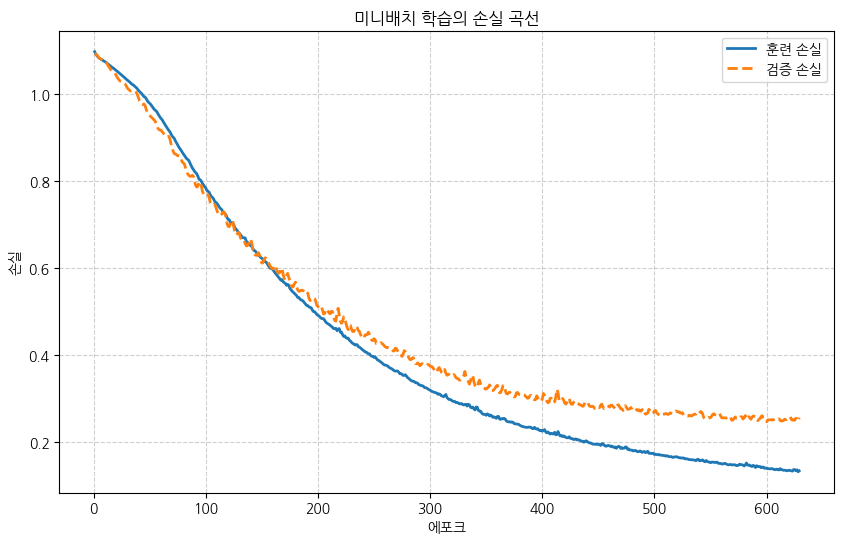

In [19]:
# 참고 - 미니배치 학습 곡선 (EpochLogger 표준)
log.plot(title='미니배치 학습의 손실 곡선', y_label='손실')

## [코드 4-17] 미니배치의 개수를 반환하는 `len(train_loader)`

데이터셋의 `len()` 은 샘플 수이지만, 데이터로더의 `len()` 은 전체 미니배치 개수이다.

In [20]:
# 코드 4-17 - 미니배치의 개수를 반환하는 len(train_loader)

print(f'훈련 미니배치의 개수: {len(train_loader)}개')   
print(f'검증 미니배치의 개수: {len(valid_loader)}개')   

훈련 미니배치의 개수: 3개
검증 미니배치의 개수: 1개


## 참고 - 데이터셋을 합치는 방법 (연습 4-6 관련)

`random_split()` 의 반대로 여러 데이터셋을 합칠 때는 `ConcatDataset` 을 사용한다. 본문 연습 4-6(K-겹 교차 검증)에서 활용한다.

In [21]:
# 코드 4-18 - 데이터셋을 합치는 방법 ([연습 문제 4-6])

# 합치는 데이터셋은 같은 구조의 샘플을 반환하는 Dataset 객체여야 모델 학습에 사용할 수 있음
combined_dataset = ConcatDataset([train_set, valid_set, test_set])
print(f'합친 데이터셋의 샘플 수: {len(combined_dataset)}')   

합친 데이터셋의 샘플 수: 900


## 정리

- 파이토치 표준 데이터 파이프라인은 `Dataset` 으로 데이터셋을, `DataLoader` 로 데이터 공급선을 만든다.
- 데이터 변환은 의존성 주입으로 분리해 상황에 맞게 갈아 끼울 수 있다.
- `random_split()` 으로 데이터를 무작위로 섞어 용도별로 나누고, 미니배치 학습에서는 가중 평균 손실을 사용한다.

> 노트북 결과는 시드 42 기준이므로 본문 수치와 다를 수 있다. (출력 수치 반영은 2 단계 작업에서 다룬다.)